# **Census Income (KDD) - Predicting Income Above/Below $50K**

**Students:** Hannah Bunnag & Zane Coons

**Course:** DATA 3421 - Data Mining, Summer 2026

**Dataset:** [Census-Income (KDD), UCI ML Repository, ID 117](https://archive.ics.uci.edu/dataset/117/census+income+kdd)

## Research Question

Can demographic and employment-related attributes (age, education, occupation,
marital status, hours worked, etc.) collected in the U.S. Census Bureau's 1994-1995
Current Population Surveys predict whether an individual's total personal income
exceeds $50,000/year? This is a **binary classification** task.

**Relevance:** Income prediction from census-style demographic data is a
long-standing benchmark problem in data mining, with direct applications in
policy analysis, targeted social program eligibility screening, and economic
research. This dataset is also considerably larger (~299K rows, 41 features)
than the more commonly used "Adult" dataset (~48K rows, 14 features) drawn from
the same underlying source, giving more statistical power but also more
real-world messiness (heavier class imbalance, more missingness, more
high-cardinality categorical features) to contend with.

We will build and compare three classifiers - **Random Forest**, **XGBoost**,
and a **Bayesian classifier** `(& potentially more, not sure yet, lets see how these models do)` - to predict this income class, following the
same data preparation -> model -> compare -> conclude structure used in prior labs.

## Feature Dictionary

Every column in this dataset uses a short, non-obvious Census Bureau code
(e.g. `AAGE`, `ACLSWKR`, `ADTOCC`) rather than a descriptive name. Before any
further work, here's a full mapping from code to plain-language meaning,
sourced directly from the UCI dataset documentation's internal column-name
crosswalk.

**Two naming discrepancies are worth flagging up front**, since they could
cause confusion later: the `ucimlrepo`-fetched column names `ADTINK` and
`GAPLOSS` do not exactly match the UCI documentation's own crosswalk, which
lists these as `ADTIND` (industry code) and `CAPLOSS` (capital losses)
respectively. These are treated as the same fields - almost certainly a minor
transcription difference in how `ucimlrepo` packaged the column headers - and
labeled accordingly below.

In [1]:
# Counterintuitive - but for the time being and formattings sake, these 2 cells
# are run after everything else in the cell (libraries are not loaded yet)

# Feature dictionary: code -> plain-language description, sourced from the
# UCI Census-Income (KDD) documentation's internal column-name crosswalk
feature_dictionary = {
    "AAGE":      "Age",
    "ACLSWKR":   "Class of worker",
    "ADTINK":    "Industry code (documented as ADTIND)",
    "ADTOCC":    "Occupation code",
    "AHGA":      "Education level",
    "AHSCOL":    "Enrolled in educational institution last week",
    "AMARITL":   "Marital status",
    "AMJIND":    "Major industry code",
    "AMJOCC":    "Major occupation code",
    "ARACE":     "Race",
    "AREORGN":   "Hispanic origin",
    "ASEX":      "Sex",
    "AUNMEM":    "Member of a labor union",
    "AUNTYPE":   "Reason for unemployment",
    "AWKSTAT":   "Full or part time employment status",
    "CAPGAIN":   "Capital gains",
    "GAPLOSS":   "Capital losses (documented as CAPLOSS)",
    "DIVVAL":    "Dividends from stocks",
    "FILESTAT":  "Tax filer status",
    "GRINREG":   "Region of previous residence",
    "GRINST":    "State of previous residence",
    "HHDFMX":    "Detailed household and family status",
    "HHDREL":    "Detailed household summary in household",
    "MARSUPWRT": "Instance weight (documented as MARSUPWT) - excluded from modeling",
    "MIGMTR1":   "Migration code, change in MSA",
    "MIGMTR3":   "Migration code, change in region",
    "MIGMTR4":   "Migration code, move within region",
    "MIGSAME":   "Lived in this house 1 year ago",
    "MIGSUN":    "Migration, previous residence in Sun Belt",
    "NOEMP":     "Number of persons worked for employer",
    "PARENT":    "Family members under 18",
    "PEFNTVTY":  "Country of birth, father",
    "PEMNTVTY":  "Country of birth, mother",
    "PENATVTY":  "Country of birth, self",
    "PRCITSHP":  "Citizenship",
    "SEOTR":     "Own business or self-employed",
    "VETQVA":    "Fill inc. questionnaire for veteran's admin",
    "VETYN":     "Veterans benefits",
    "WKSWORK":   "Weeks worked in year",
    "AHRSPAY":   "Wage per hour",
    "year":      "Survey year (94 = 1994, 95 = 1995)",
    "income":    "TARGET - income class (above/below $50,000/year)",
}

# Build the reference table: code, description, role, and inferred type
data_dict = pd.DataFrame({
    "Code": list(feature_dictionary.keys()),
    "Description": list(feature_dictionary.values()),
})

data_dict["Role"] = np.select(
    [data_dict["Code"] == "income", data_dict["Code"] == "MARSUPWRT"],
    ["Target", "Excluded (weighting only)"],
    default="Feature"
)

# Reclassified numeric/categorical typing from Section 1.3's structural review
true_numeric_cols = ["AAGE", "CAPGAIN", "GAPLOSS", "DIVVAL", "NOEMP", "WKSWORK", "AHRSPAY"]
data_dict["Type"] = np.where(
    data_dict["Code"].isin(true_numeric_cols), "Numeric",
    np.where(data_dict["Role"] == "Target", "Target (binary)", "Categorical")
)

data_dict = data_dict[["Code", "Description", "Role", "Type"]].reset_index(drop=True)
data_dict

NameError: name 'pd' is not defined

In [2]:
# Visual reference chart: color-coded by Role, for quick scanning
fig, ax = plt.subplots(figsize=(11, 14))
ax.axis("off")

role_colors = {
    "Feature": "#EAF2FB",
    "Target": "#FDE8D7",
    "Excluded (weighting only)": "#F0F0F0"
}
cell_colors = [[role_colors[row.Role]] * 4 for row in data_dict.itertuples()]

table = ax.table(
    cellText=data_dict.values,
    colLabels=data_dict.columns,
    cellColours=cell_colors,
    cellLoc="left",
    loc="center",
    colWidths=[0.12, 0.5, 0.22, 0.16]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

for j in range(4):
    table[(0, j)].set_facecolor("#4C72B0")
    table[(0, j)].set_text_props(color="white", weight="bold")

plt.title("Census-Income (KDD) - Feature Dictionary", fontsize=13, weight="bold", pad=20)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

---

In [3]:
# Global imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Modeling (used starting in later sections)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

RANDOM_STATE = 2324  # keep consistent across the notebook for reproducibility

# NOTE: Uncomment and run this once, or just refer to the info below

# pip install ucimlrepo

---

## 1. Data Preparation:
- Data Exploration: Conduct a thorough initial analysis of the raw Census-Income
  (KDD) data - structure, data types, target variable, and class balance -
  before any cleaning or transformation is applied.
- Confirm the target variable and classification task.
- Establish a first-pass understanding of which columns are genuinely numeric
  vs. categorical codes stored as integers, since this dataset is
  predominantly categorical (32 categorical, 7 numerical, 2 binary features
  per the UCI documentation)

In [4]:
# Load the data
UCI_DATASET_ID = 117  # Census-Income (KDD)

dataset = fetch_ucirepo(id=UCI_DATASET_ID)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
TARGET_COL = "income"                  # confirmed directly (y_raw's single column)
INSTANCE_WEIGHT_COL = "MARSUPWRT"      # ucimlrepo's name for the Census Bureau's MARSUPWT

print(f"Shape: {df.shape}")
print(f"Target column: '{TARGET_COL}'")
print(f"Instance-weight column: '{INSTANCE_WEIGHT_COL}' (excluded from modeling per UCI docs)")
df.head(10)

Shape: (199523, 42)
Target column: 'income'
Instance-weight column: 'MARSUPWRT' (excluded from modeling per UCI docs)


,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,AREORGN,ASEX,AUNMEM,AUNTYPE,AWKSTAT,CAPGAIN,GAPLOSS,DIVVAL,FILESTAT,GRINREG,GRINST,HHDFMX,HHDREL,MARSUPWRT,MIGMTR1,MIGMTR3,MIGMTR4,MIGSAME,MIGSUN,NOEMP,PARENT,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
5,48,Private,40,10,Some college but no degree,Not in universe,Married-civilian spouse present,Entertainment,Professional specialty,Amer Indian Aleut or Eskimo,All other,Female,No,Not in universe,Full-time schedules,0,0,0,Joint both under 65,Not in universe,Not in universe,Spouse of householder,Spouse of householder,162.61,NaN,NaN,NaN,Not in universe under 1 year old,NaN,1,Not in universe,Philippines,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,1200,95,-50000
6,42,Private,34,3,Bachelors degree(BA AB BS),Not in universe,Married-civilian spouse present,Finance insurance and real estate,Executive admin and managerial,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,5178,0,0,Joint both under 65,Not in universe,Not in universe,Householder,Householder,1535.86,Nonmover,Nonmover,Nonmover,Yes,Not in universe,6,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
7,28,Private,4,40,High school graduate,Not in universe,Never married,Construction,Handlers equip cleaners etc,White,All other,Female,Not in universe,Job loser - on layoff,Unemployed full-time,0,0,0,Single,Not in universe,Not in universe,Secondary individual,Nonrelative of house

### 1.1 Dataset Structure

Before any cleaning, it's worth getting a full structural picture of the raw
data: how many rows/columns, what data types pandas inferred, which columns
are numeric vs. categorical, and a first look at scale/range for the numeric
fields.

In [5]:
# Full structural summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AAGE       199523 non-null  int64  
 1   ACLSWKR    199523 non-null  str    
 2   ADTINK     199523 non-null  int64  
 3   ADTOCC     199523 non-null  int64  
 4   AHGA       199523 non-null  str    
 5   AHSCOL     199523 non-null  str    
 6   AMARITL    199523 non-null  str    
 7   AMJIND     199523 non-null  str    
 8   AMJOCC     199523 non-null  str    
 9   ARACE      199523 non-null  str    
 10  AREORGN    199523 non-null  str    
 11  ASEX       199523 non-null  str    
 12  AUNMEM     199523 non-null  str    
 13  AUNTYPE    199523 non-null  str    
 14  AWKSTAT    199523 non-null  str    
 15  CAPGAIN    199523 non-null  int64  
 16  GAPLOSS    199523 non-null  int64  
 17  DIVVAL     199523 non-null  int64  
 18  FILESTAT   199523 non-null  str    
 19  GRINREG    199523 non-null  str   

In [6]:
# Numeric summary - only meaningful for columns pandas actually inferred as numeric
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AAGE,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0
ADTINK,199523.0,15.352320,18.067129,0.00,0.000,0.00,33.00,51.0
ADTOCC,199523.0,11.306556,14.454204,0.00,0.000,0.00,26.00,46.0
CAPGAIN,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0
GAPLOSS,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0
DIVVAL,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0
MARSUPWRT,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3
NOEMP,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0
SEOTR,199523.0,0.175438,0.553694,0.00,0.000,0.00,0.00,2.0
VETYN,199523.0,1.514833,0.851473,0.00,2.000,2.00,2.00,2.0


In [7]:
# Explicit dtype breakdown, since df.info() output is long with 41 columns
dtype_counts = df.dtypes.value_counts()
print("Column count by inferred dtype:")
print(dtype_counts)
print()

numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_raw = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols_raw)}): {numeric_cols_raw}")
print()
print(f"Categorical/object columns ({len(categorical_cols_raw)}): {categorical_cols_raw}")

Column count by inferred dtype:
str        29
int64      12
float64     1
Name: count, dtype: int64

Numeric columns (13): ['AAGE', 'ADTINK', 'ADTOCC', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'MARSUPWRT', 'NOEMP', 'SEOTR', 'VETYN', 'WKSWORK', 'AHRSPAY', 'year']

Categorical/object columns (29): ['ACLSWKR', 'AHGA', 'AHSCOL', 'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX', 'AUNMEM', 'AUNTYPE', 'AWKSTAT', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN', 'PARENT', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'VETQVA', 'income']


### 1.2 Target Variable - `income`

The target column is confirmed as `income`, matching the UCI documentation's
description of a binary income class (income binned at the $50K/year level).
Below, we look at both the raw class labels (the exact strings used, since
these datasets often store them with leading/trailing whitespace or a
trailing period, e.g. `" 50000+."`) and the class balance.

In [8]:
print("Raw target class labels:")
print(df[TARGET_COL].unique())
print()
print("Class counts:")
print(df[TARGET_COL].value_counts())
print()
print("Class proportions:")
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Raw target class labels:
<StringArray>
['-50000', ' 50000+.']
Length: 2, dtype: str

Class counts:
income
-50000      187141
 50000+.     12382
Name: count, dtype: int64

Class proportions:
income
-50000      93.79 %
 50000+.     6.21 %
Name: proportion, dtype: str


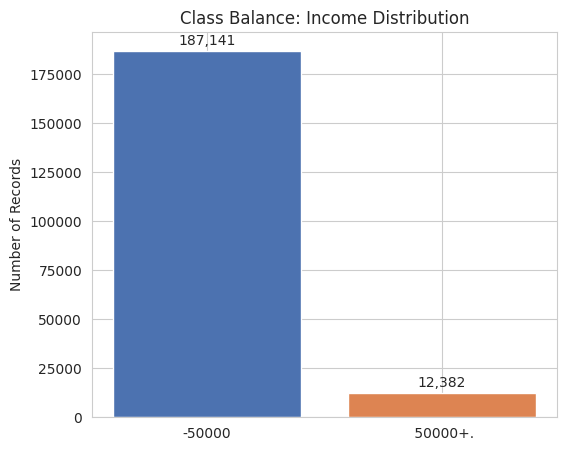

In [9]:
# Visualize the class balance directly
class_counts = df[TARGET_COL].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(class_counts.index.astype(str), class_counts.values, color=["#4C72B0", "#DD8452"])
plt.ylabel("Number of Records")
plt.title("Class Balance: Income Distribution")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 3000, f"{v:,}", ha="center")
plt.show()

### 1.3 First Observations

**Row/column count:** confirmed **199,523 rows, 42 columns** (41 features +
`income`), matching the UCI-documented training-file size exactly. This is the
training portion only - the official source also has a separate 99,762-row
test file, not returned by `fetch_ucirepo` (see the pull-the-test-file
discussion above); we'll decide in Section 5 whether to draw our own split
from this file or bring in that official test file.

**Target / class imbalance:** confirmed two raw values - `'-50000'` and
`' 50000+.'` - split **93.79% / 6.21%** (187,141 vs. 12,382 records). This is
more skewed than the ~94%/6% figure commonly cited for this dataset. This has
real consequences going forward:
- Plain accuracy will be close to useless on its own - a model that always
  predicts `'-50000'` already scores ~93.8% accuracy while being completely
  uninformative. Precision/recall/F1/AUC on the minority (`' 50000+.'`) class
  need to be the primary metrics from the first model onward, not something
  bolted on at the end.
- `class_weight="balanced"` / `scale_pos_weight` , and may be worth building in from the
  start rather than deferring to a single closing section.

**Dtype breakdown:** pandas inferred **13 numeric** and **29 string
(categorical)** columns, roughly consistent with the UCI documentation's own
32 categorical / 7 numeric / 2 binary summary.

**Numeric columns that are actually categorical codes in disguise:**
- `ADTINK` (industry code) and `ADTOCC` (occupation code) - range 0-51 / 0-46
  with a median of exactly 0; these are categorical codes, not a meaningful
  numeric scale.
- `SEOTR` (own business/self-employed) and `VETYN` (veterans benefits) - only
  take values in {0, 1, 2}, i.e. categorical flags.
- `year` - only takes values {94, 95} (survey year), categorical by nature.
- `AAGE`, `CAPGAIN`, `GAPLOSS`, `DIVVAL`, `MARSUPWRT`, `NOEMP`, `WKSWORK`,
  `AHRSPAY` are genuinely continuous/count numeric fields.

The effective categorical column count is closer to **33-34**, not 29 - an
explicit `NUMERIC_COLS` / `CATEGORICAL_COLS` list will be built by hand in
Section 5 rather than relying on `select_dtypes` alone.

**Skew in the continuous numeric fields:** `CAPGAIN`, `GAPLOSS`, `DIVVAL`, and
`AHRSPAY` all show a median of **0** but a max in the thousands (up to 99,999
for `CAPGAIN`/`DIVVAL`) - heavily right-skewed, zero-inflated distributions,
unlike the roughly-normal `AAGE`. Worth visualizing directly in the EDA
section before deciding whether any transformation is warranted.

**Missing values already visible in `df.info()`**, separate from the `"?"`
marker check still to come:
- `GRINST` (708 missing), `PEFNTVTY` (6,713), `PEMNTVTY` (6,119), `PENATVTY`
  (3,393) - plausible genuine missingness.
- `MIGMTR1`, `MIGMTR3`, `MIGMTR4`, `MIGSUN` - all sit at exactly **99,827**
  non-null (~50% missing). That precise, repeated number strongly suggests
  these migration questions were only asked of a sub-population, rather than
  random missingness - worth checking against `MIGSAME` ("lived in this house
  1 year ago") next, before deciding whether to impute or category-encode.

This means Section 2's missing-value check needs to cover **three** cases, not
two: literal `"?"` markers, already-native `NaN` entries (found here), and the
`"Not in universe"` pseudo-category.

---

## 2. Data Cleaning

Before touching missing values or duplicates, there's one structural issue
specific to this dataset that has to be handled first: the **instance
weight** column.

- The UCI documentation explicitly states: *"The instance weight indicates the
  number of people in the population that each record represents due to
  stratified sampling... This attribute should not be used in the
  classifiers."*
- In the `ucimlrepo`-fetched frame this column is named `MARSUPWRT`
  (the Census Bureau's internal name is `MARSUPWT`, "March Supplement
  Weight"). It's dropped from the modeling features now and kept separately
  in case it's useful later for a population-weighted sanity check.

Missing values are then checked in **two** categories (a literal `"?"`
marker - common in the related Adult/Census-Income dataset - was checked and
confirmed **not present anywhere** in this dataset, so that category is
skipped entirely below):

1. **Native missing values** - several columns (`GRINST`, `PEFNTVTY`,
   `PEMNTVTY`, `PENATVTY`, `MIGMTR1`, `MIGMTR3`, `MIGMTR4`, `MIGSUN`) contain
   real `NaN` entries as parsed directly by pandas.
2. **`"Not in universe"` category** - not missing data. It means the
   question didn't apply to that respondent (e.g. "major industry code" for
   someone outside the labor force). Kept as its own valid category.

In [10]:
# Full column list, to confirm the exact name against the UCI variable table
# df.columns.tolist()

In [11]:
# Category 2: literal "?" missing markers, counted separately before converting
#   na_marker_counts = (df_model == "?").sum() + (df_model == " ?").sum()
#   na_marker_counts = na_marker_counts[na_marker_counts > 0].sort_values(ascending=False)

#   print(f"Columns using a literal '?' missing marker: {len(na_marker_counts)}")
#   na_marker_counts

In [12]:
# Drop the instance-weight column from the modeling frame, keep it aside
# INSTANCE_WEIGHT_COL = "MARSUPWRT" <- Defined above now

instance_weights = df[INSTANCE_WEIGHT_COL].copy()
df_model = df.drop(columns=[INSTANCE_WEIGHT_COL])

print(f"Dropped '{INSTANCE_WEIGHT_COL}' from modeling frame.")
print(f"df_model shape: {df_model.shape}")

Dropped 'MARSUPWRT' from modeling frame.
df_model shape: (199523, 41)


In [13]:
# Category 1: native missing values
null_counts = df_model.isnull().sum()
null_pct = (null_counts / len(df_model) * 100).round(2)

null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)

print(f"Columns with native missing values: {len(null_summary)} / {df_model.shape[1]}")
null_summary

Columns with native missing values: 8 / 41


,n_missing,pct_missing
MIGMTR1,99696,49.97
MIGMTR3,99696,49.97
MIGMTR4,99696,49.97
MIGSUN,99696,49.97
PEFNTVTY,6713,3.36
PEMNTVTY,6119,3.07
PENATVTY,3393,1.70
GRINST,708,0.35


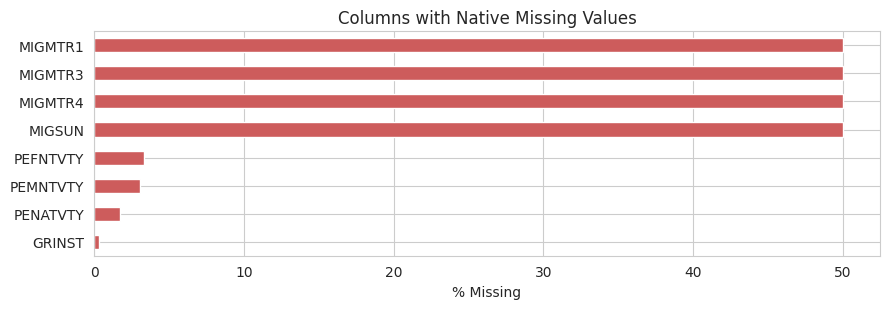

In [14]:
fig, ax = plt.subplots(figsize=(9, max(3, len(null_summary) * 0.4)))
null_summary["pct_missing"].sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("% Missing")
ax.set_title("Columns with Native Missing Values")
plt.tight_layout()
plt.show()

In [15]:
# Category 2: "Not in universe" - confirmed as a category, not noise
niu_counts = df_model.astype(str).apply(lambda col: col.str.strip().eq("Not in universe").sum())
niu_counts = niu_counts[niu_counts > 0].sort_values(ascending=False)

print(f"Columns containing a 'Not in universe' category: {len(niu_counts)}")
niu_counts

Columns containing a 'Not in universe' category: 13


VETQVA     197539
AUNTYPE    193453
AHSCOL     186943
GRINREG    183750
GRINST     183750
AUNMEM     180459
PARENT     144232
AMJOCC     100684
ACLSWKR    100245
MIGSUN      84054
MIGMTR1      1516
MIGMTR3      1516
MIGMTR4      1516
dtype: int64

### Checking the Migration Columns Specifically

`MIGMTR1`, `MIGMTR3`, `MIGMTR4`, and `MIGSUN` all show ~50% native missing -
suspiciously identical across four unrelated columns. `MIGSAME` ("lived in
this house 1 year ago") is the natural column to check this against.

In [16]:
# Cross-check: is the migration-detail missingness explained by a MIGSAME skip pattern?
print(df_model["MIGSAME"].value_counts())
print()

migsame_vs_missing = df_model.groupby(df_model["MIGSAME"], dropna=False)["MIGMTR1"].apply(
    lambda s: s.isnull().sum()
)
print("Missing MIGMTR1 count, broken out by MIGSAME response:")
print(migsame_vs_missing)

MIGSAME
Not in universe under 1 year old    101212
Yes                                  82538
No                                   15773
Name: count, dtype: int64

Missing MIGMTR1 count, broken out by MIGSAME response:
MIGSAME
No                                      0
Not in universe under 1 year old    99696
Yes                                     0
Name: MIGMTR1, dtype: int64


**Confirmed:** every `MIGMTR1` `NaN` corresponds exactly to
`MIGSAME == "Not in universe under 1 year old"` (99,696 of 101,212 such
respondents; the other 1,516 already carry the literal `"Not in universe"`
string in `MIGMTR1` instead - same underlying case, inconsistently encoded).
This is a structural "not applicable" pattern, not missing data to impute -
so it's standardized to the `"Not in universe"` category these columns
already use, rather than imputed.

In [17]:
migration_cols = ["MIGMTR1", "MIGMTR3", "MIGMTR4", "MIGSUN"]
df_clean = df_model.copy()

for col in migration_cols:
    df_clean[col] = df_clean[col].fillna("Not in universe")

print(df_clean[migration_cols].isnull().sum())

MIGMTR1    0
MIGMTR3    0
MIGMTR4    0
MIGSUN     0
dtype: int64


### Genuine Missing Values - `PEFNTVTY`, `PEMNTVTY`, `PENATVTY`, `GRINST`

These four remaining columns are true, unexplained missingness (no skip
pattern), all categorical, at manageable rates (0.35%-3.36%). Filled with an
explicit `"Missing"` category rather than mode-imputed, to avoid fabricating
a specific value (e.g. a specific country of birth) the data doesn't support.

In [18]:
genuine_missing_cols = ["PEFNTVTY", "PEMNTVTY", "PENATVTY", "GRINST"]

for col in genuine_missing_cols:
    df_clean[col] = df_clean[col].fillna("Missing")

print(df_clean[genuine_missing_cols].isnull().sum())
print()
print(f"Any remaining missing values in df_clean: {df_clean.isnull().sum().sum()}")

PEFNTVTY    0
PEMNTVTY    0
PENATVTY    0
GRINST      0
dtype: int64

Any remaining missing values in df_clean: 0


### Duplicate Rows

Checked on the cleaned frame. Given the dataset's heavily categorical,
low-cardinality composition, two different people sharing an identical row
is expected at this scale, not a sign of erroneous data collection.

In [19]:
duplicate_count = df_clean.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_count} ({duplicate_count / len(df_clean) * 100:.2f}% of rows)")

Number of fully duplicated rows: 46627 (23.37% of rows)


**Decision: duplicates are kept, not dropped.** With dozens of low-variance
categorical columns (many with only 2-3 levels, several `"Not in universe"`
for the large share of respondents outside the labor force), exact-row
coincidence across different people is expected here - unlike a patient-
record dataset, there's no strong reason to treat a match as necessarily the
*same* record.

### Cleaning Summary

- `MARSUPWRT` (instance weight) dropped from the modeling frame per UCI
  documentation; preserved separately as `instance_weights`.
- No literal `"?"` missing markers exist anywhere in this dataset (checked
  and confirmed absent - a real difference from the related Adult dataset).
- `MIGMTR1`/`MIGMTR3`/`MIGMTR4`/`MIGSUN`'s ~50% "missingness" was fully
  explained by a structural skip pattern (`MIGSAME == "Not in universe under
  1 year old"`) and standardized to the `"Not in universe"` category already
  used elsewhere in these columns.
- `PEFNTVTY`, `PEMNTVTY`, `PENATVTY`, `GRINST` (true, unexplained missingness,
  0.35%-3.36%) were filled with an explicit `"Missing"` category.
- 46,627 duplicate rows (23.37%) were identified and deliberately **retained**.
- `df_clean` now has zero missing values and is ready for EDA.

In [20]:
print(f"Final df_clean shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Final df_clean shape: (199523, 41)
Total missing values: 0


,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,AREORGN,ASEX,AUNMEM,AUNTYPE,AWKSTAT,CAPGAIN,GAPLOSS,DIVVAL,FILESTAT,GRINREG,GRINST,HHDFMX,HHDREL,MIGMTR1,MIGMTR3,MIGMTR4,MIGSAME,MIGSUN,NOEMP,PARENT,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,Not in universe,Not in universe,Not in universe,Not in universe under 1 year old,Not in universe,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,Not in universe,Not in universe,Not in universe,Not in universe under 1 year old,Not in universe,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000


---

## 3. Exploratory Data Analysis:
- Numeric Feature Distributions: Examine the shape, skew, and scale of the
  small set of genuinely continuous numeric fields identified in Section 1.
- Outlier Detection: Apply an IQR-based check to the numeric fields, keeping
  in mind several are naturally zero-inflated (most respondents report $0 in
  capital gains/losses/dividends), so "outlier" here often means "real
  high earner," not a data error.
- Correlation Analysis: Numeric-feature correlations, including against the
  target (encoded numerically for this purpose only).
- Categorical Features vs. Target: With ~34 categorical/coded columns and
  only 7 truly continuous ones, most of this dataset's signal will come from
  categorical relationships, not numeric ones.
- Class Balance Recap: Carried over from Section 1, kept in view throughout
  since every visualization below needs to be read with the 93.8%/6.2% split
  in mind.

In [21]:
# Define the working numeric/categorical column lists explicitly,
# using the reclassification established in Section 1.3 / the Feature Dictionary
# (NOT pandas' select_dtypes, which mis-groups several coded columns as numeric)
NUMERIC_COLS = ["AAGE", "CAPGAIN", "GAPLOSS", "DIVVAL", "NOEMP", "WKSWORK", "AHRSPAY"]
CATEGORICAL_COLS = [c for c in df_clean.columns if c not in NUMERIC_COLS + [TARGET_COL]]

print(f"Numeric columns ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical columns ({len(CATEGORICAL_COLS)}): {len(CATEGORICAL_COLS)} total")

Numeric columns (7): ['AAGE', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'NOEMP', 'WKSWORK', 'AHRSPAY']
Categorical columns (33): 33 total


### 3.1 Numeric Feature Distributions

Histograms for the seven true numeric fields. Several are expected to be
heavily zero-inflated based on the `describe()` output in Section 1
(`CAPGAIN`, `GAPLOSS`, `DIVVAL`, `AHRSPAY` all had a median of 0), so this is
mainly to confirm that visually and see the shape of the non-zero tail.

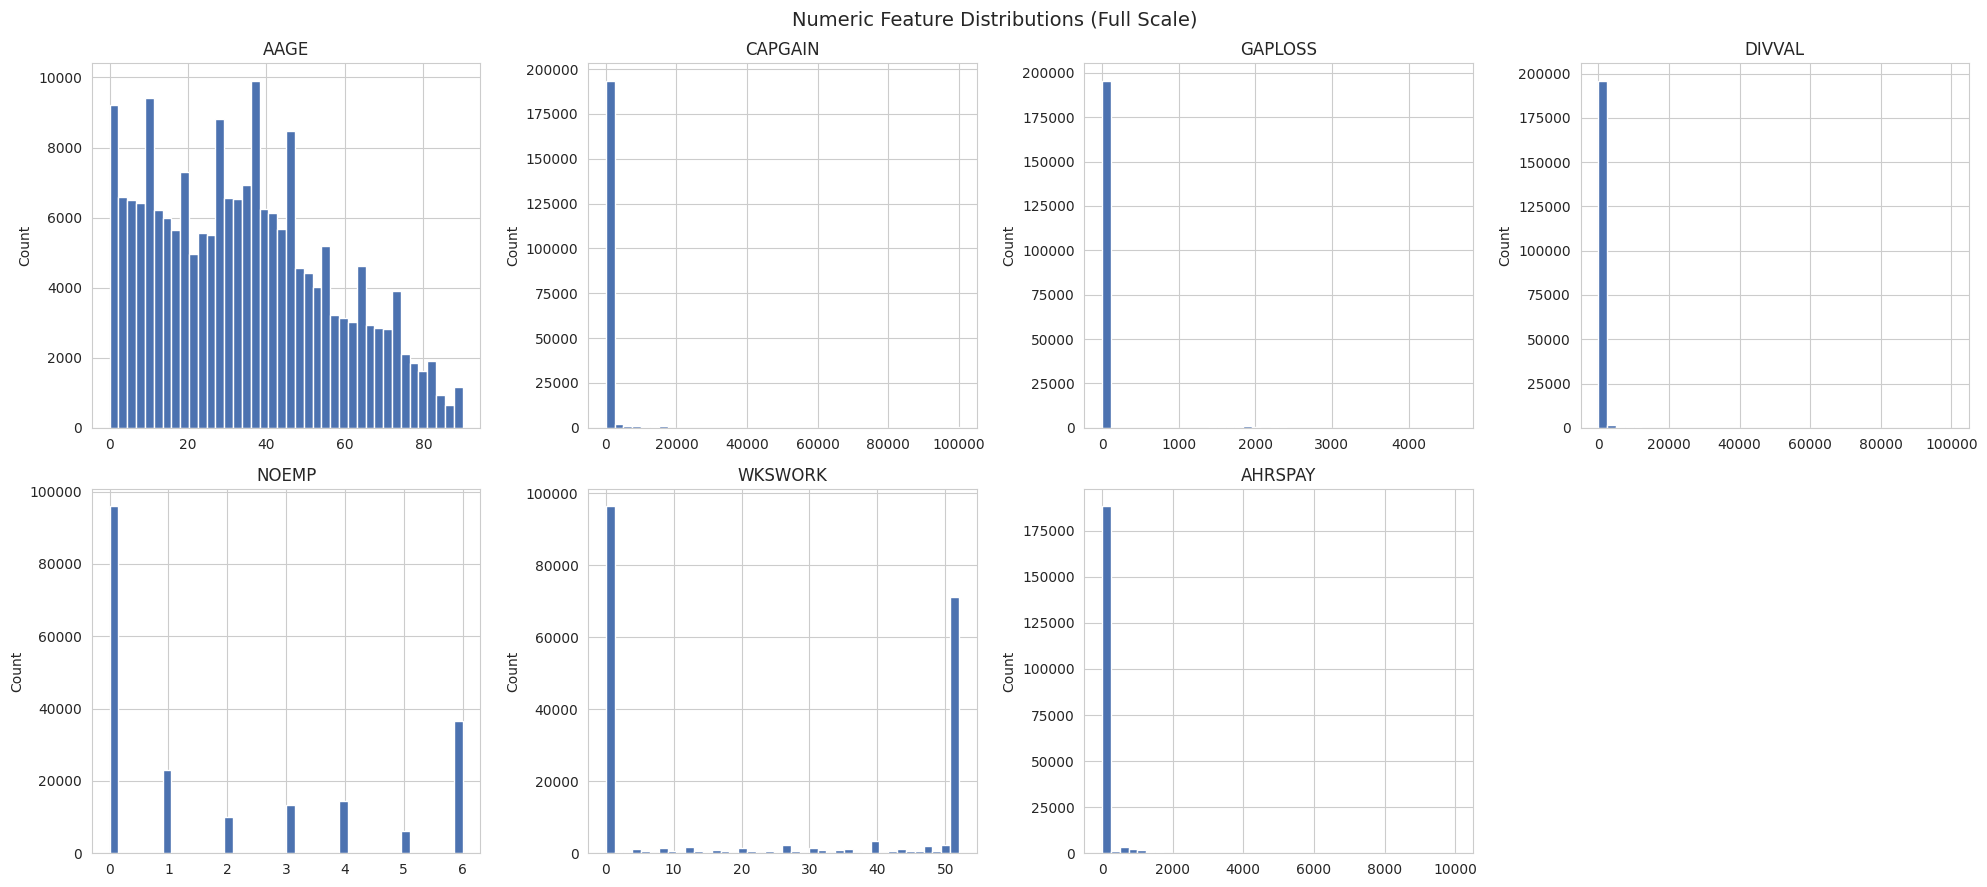

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df_clean[col], bins=40, edgecolor="white", color="#4C72B0")
    ax.set_title(col)
    ax.set_ylabel("Count")

for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].axis("off")

plt.suptitle("Numeric Feature Distributions (Full Scale)", fontsize=14)
plt.tight_layout()
plt.show()

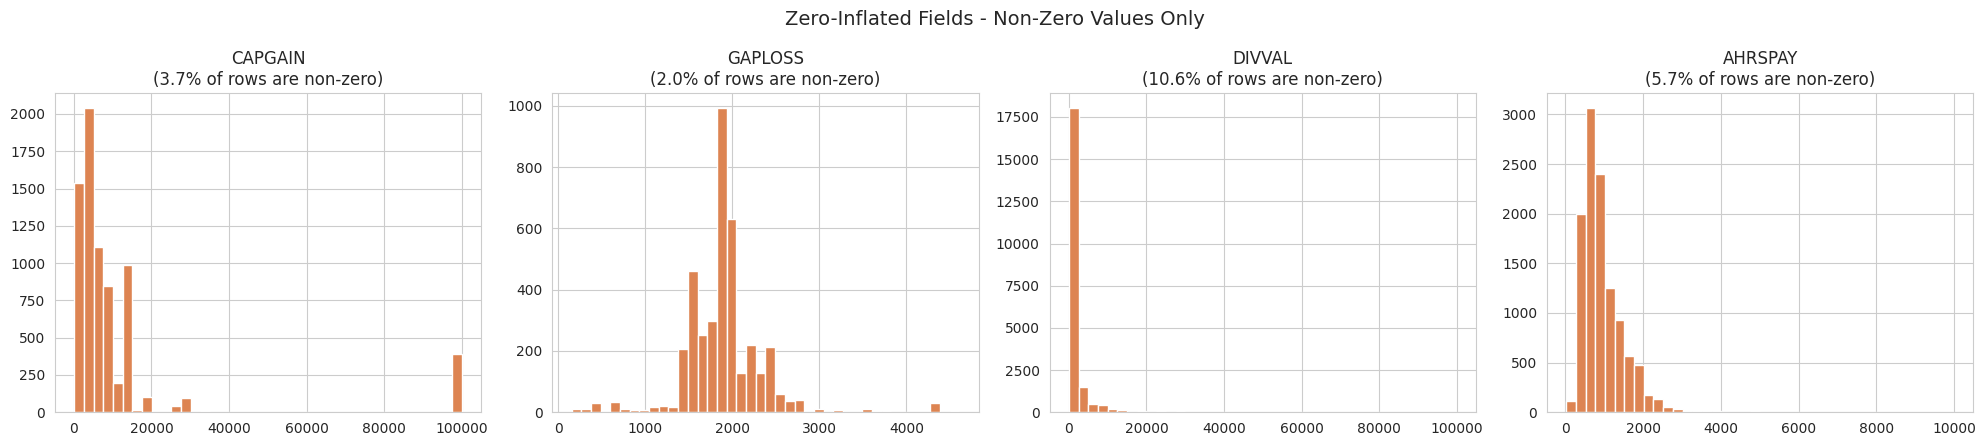

In [23]:
# Zero-inflated fields are hard to read at full scale - re-plot the non-zero
# tail only, for the four fields where the median was 0
zero_inflated_cols = ["CAPGAIN", "GAPLOSS", "DIVVAL", "AHRSPAY"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, zero_inflated_cols):
    nonzero = df_clean.loc[df_clean[col] > 0, col]
    pct_nonzero = len(nonzero) / len(df_clean) * 100
    ax.hist(nonzero, bins=40, edgecolor="white", color="#DD8452")
    ax.set_title(f"{col}\n({pct_nonzero:.1f}% of rows are non-zero)")

plt.suptitle("Zero-Inflated Fields - Non-Zero Values Only", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Outlier Detection

An IQR-based check on the numeric fields. Given the zero-inflation just
observed, the "outliers" flagged here for `CAPGAIN`/`GAPLOSS`/`DIVVAL`/`AHRSPAY`
are expected to be large in count and are not data errors - they're simply
anyone with a non-zero value at all, since the IQR itself is collapsed near
zero for these fields. `AAGE`, `NOEMP`, and `WKSWORK` are the more
meaningful columns to read this check on.

In [24]:
def iqr_outlier_count(series: pd.Series) -> tuple:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((series < lower) | (series > upper)).sum())
    return n_outliers, lower, upper

outlier_rows = []
for col in NUMERIC_COLS:
    n_out, lower, upper = iqr_outlier_count(df_clean[col])
    outlier_rows.append({
        "Feature": col,
        "n_outliers": n_out,
        "pct_outliers": round(n_out / len(df_clean) * 100, 2),
        "IQR_lower": round(lower, 2),
        "IQR_upper": round(upper, 2),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False)
outlier_summary

,Feature,n_outliers,pct_outliers,IQR_lower,IQR_upper
3,DIVVAL,21141,10.60,0.0,0.0
6,AHRSPAY,11304,5.67,0.0,0.0
1,CAPGAIN,7379,3.70,0.0,0.0
2,GAPLOSS,3906,1.96,0.0,0.0
0,AAGE,0,0.00,-37.5,102.5
4,NOEMP,0,0.00,-6.0,10.0
5,WKSWORK,0,0.00,-78.0,130.0


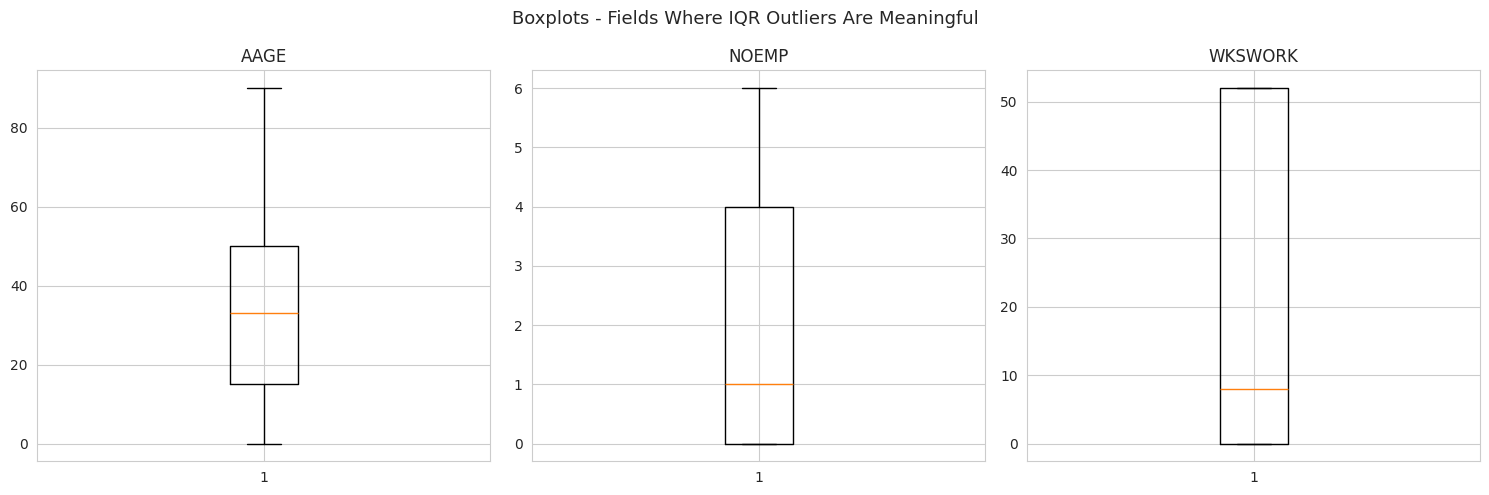

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["AAGE", "NOEMP", "WKSWORK"]):
    ax.boxplot(df_clean[col], vert=True)
    ax.set_title(col)

plt.suptitle("Boxplots - Fields Where IQR Outliers Are Meaningful", fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Correlation Matrix (Numeric Fields + Target)

Only seven fields qualify as genuinely numeric, so this correlation matrix
will necessarily be small and limited in what it can reveal on its own - most
of this dataset's predictive signal is expected to come from the categorical
relationships in 3.4, not here. The target is temporarily encoded as a binary
0/1 for this correlation check only (`' 50000+.'` = 1); this encoding is not
used anywhere else in the notebook, since the real encoding decision for
modeling is deferred to Section 5.

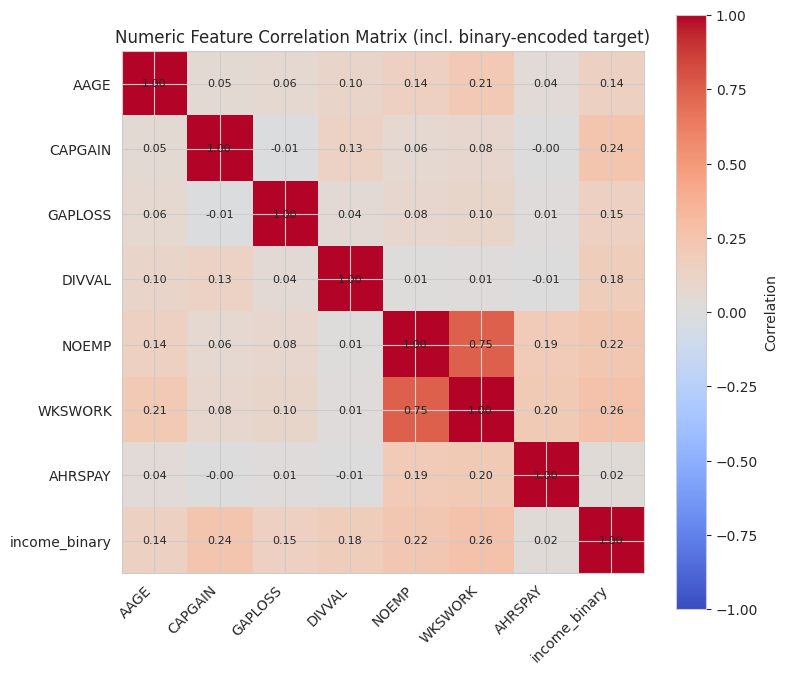

WKSWORK    0.262316
CAPGAIN    0.240725
NOEMP      0.222684
DIVVAL     0.175779
GAPLOSS    0.147417
AAGE       0.135720
AHRSPAY    0.024528
Name: income_binary, dtype: float64

In [26]:
corr_df = df_clean[NUMERIC_COLS].copy()
corr_df["income_binary"] = (df_clean[TARGET_COL] == " 50000+.").astype(int)

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 7))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Numeric Feature Correlation Matrix (incl. binary-encoded target)")
plt.tight_layout()
plt.show()

corr_matrix["income_binary"].drop("income_binary").sort_values(ascending=False)

### 3.4 Categorical Features vs. Target

The core of this dataset's signal. Rather than plotting all ~34 categorical
columns (most would be unreadable at this row count and level count), this
starts with a handful of columns most likely to be informative by domain
reasoning (education, occupation, marital status, sex, full/part-time status),
then reports high-cardinality columns separately, since those need a
different treatment (e.g. grouping rare categories) before they're usable
in a chart or a model.

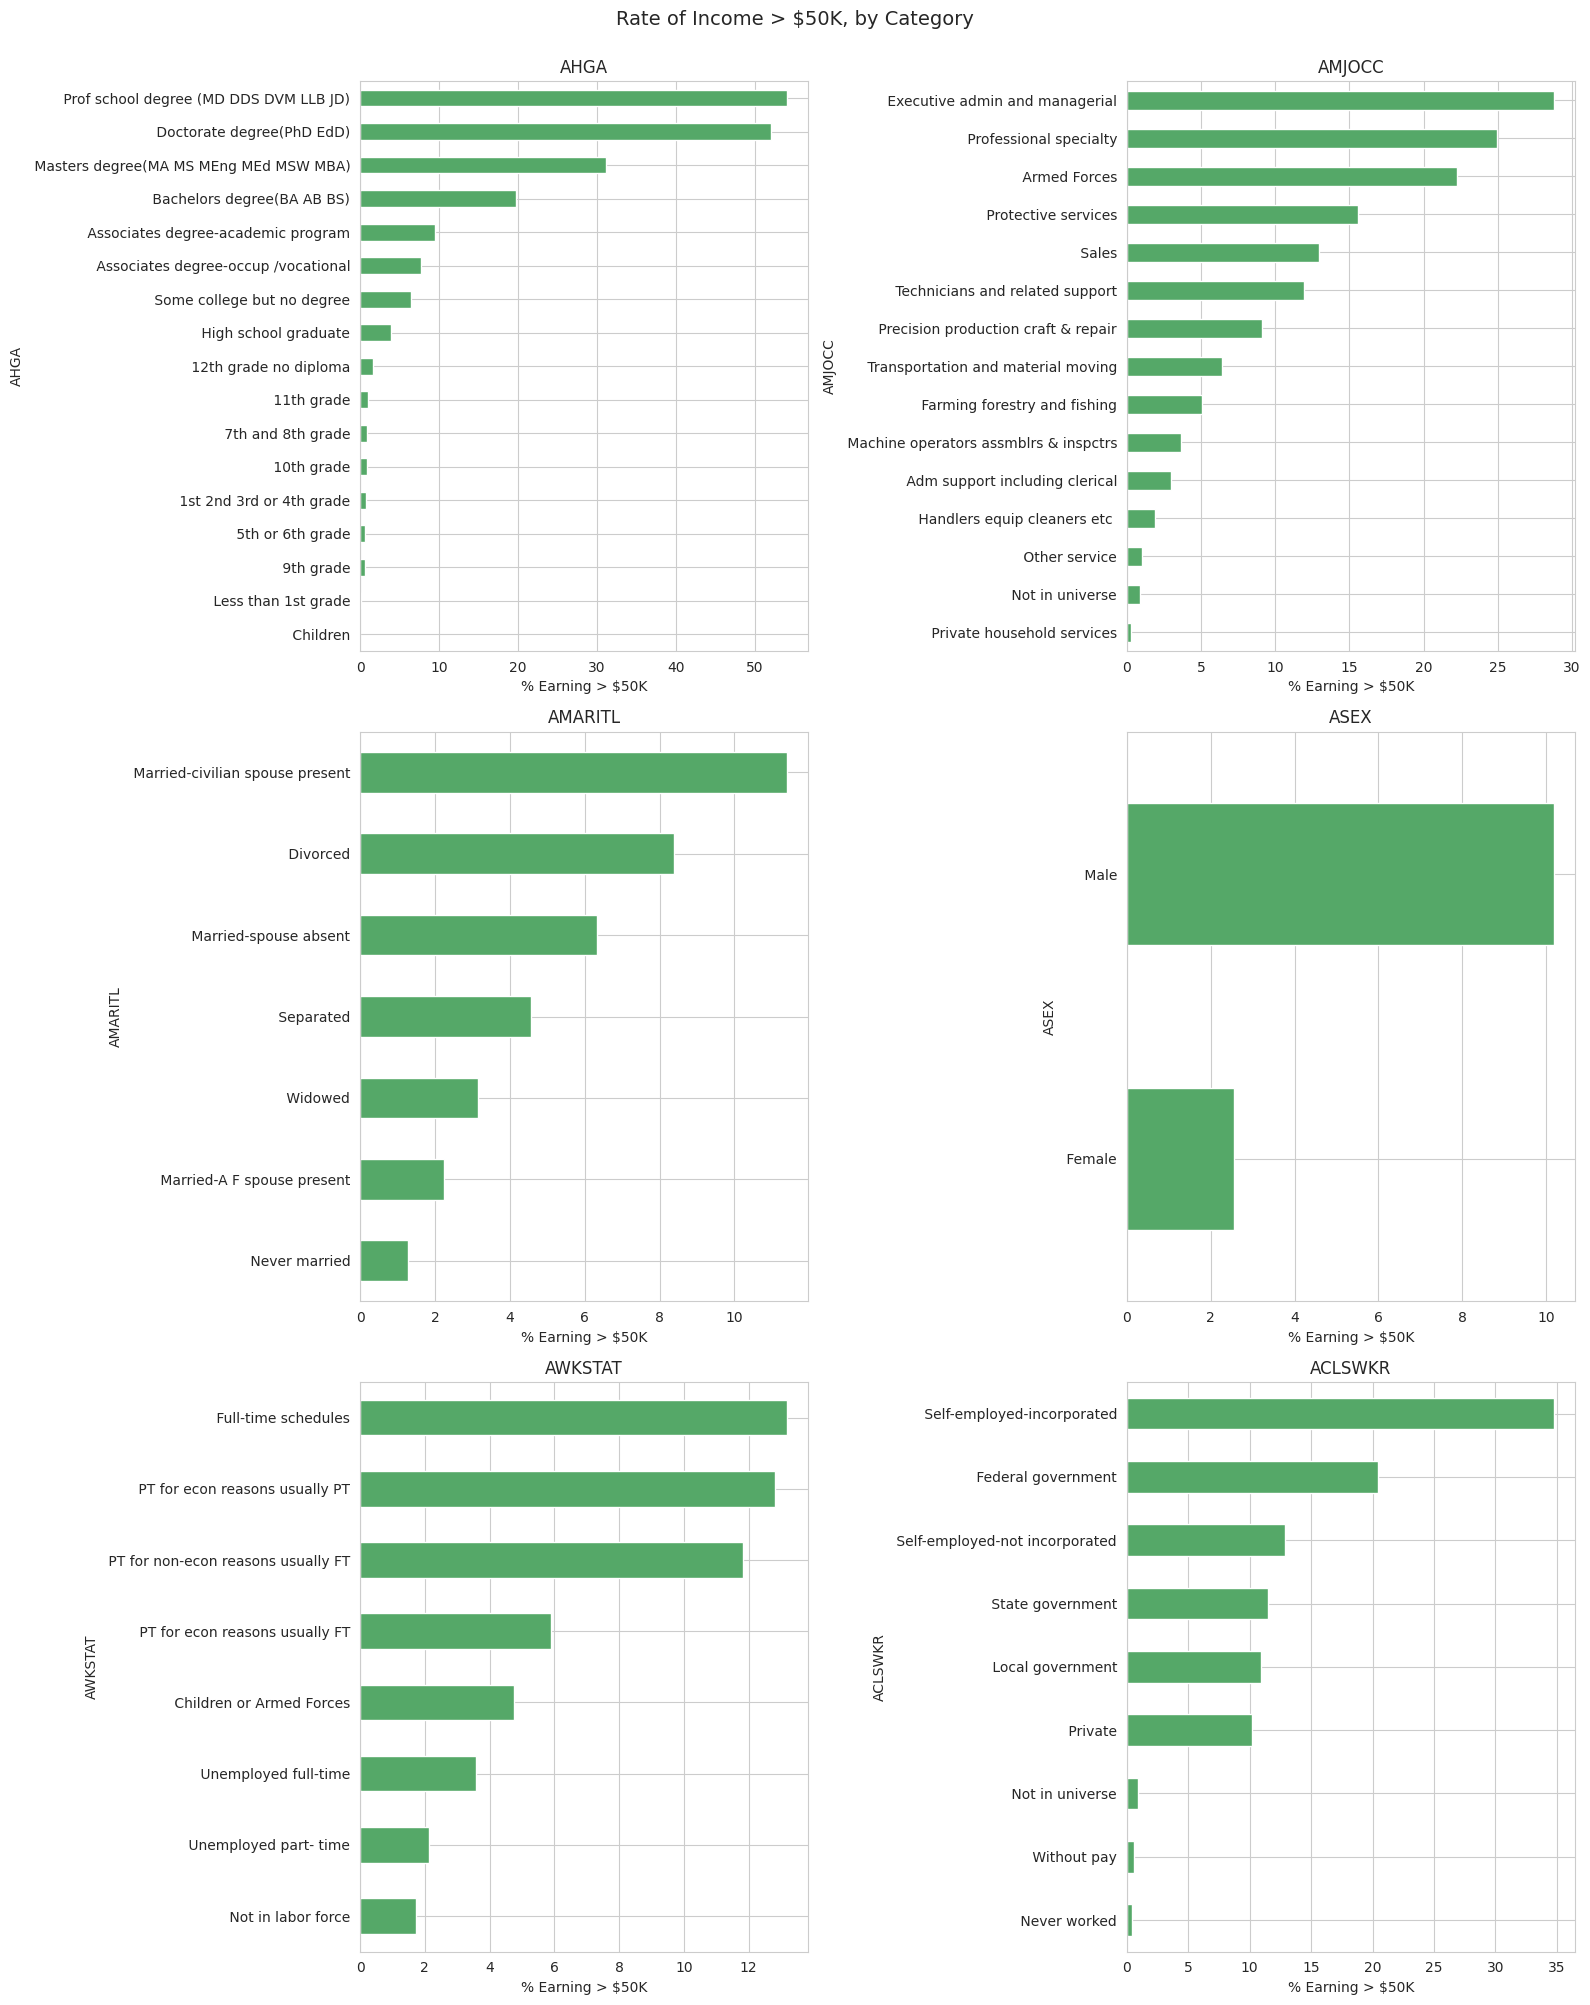

In [27]:
key_categorical_cols = ["AHGA", "AMJOCC", "AMARITL", "ASEX", "AWKSTAT", "ACLSWKR"]

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, col in zip(axes, key_categorical_cols):
    rate_by_cat = (
        df_clean.groupby(col)[TARGET_COL]
        .apply(lambda s: (s == " 50000+.").mean() * 100)
        .sort_values(ascending=False)
    )
    rate_by_cat.plot(kind="barh", ax=ax, color="#55A868")
    ax.set_xlabel("% Earning > $50K")
    ax.set_title(col)
    ax.invert_yaxis()

plt.suptitle("Rate of Income > $50K, by Category", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [28]:
# Raw numbers behind the categorical-vs-target bar charts - income rate,
# with counts, per category, for each key column
for col in key_categorical_cols:
    print(f"=== {col} ===")
    summary = df_clean.groupby(col)[TARGET_COL].agg(
        n="count",
        pct_above_50k=lambda s: round((s == " 50000+.").mean() * 100, 2)
    ).sort_values("pct_above_50k", ascending=False)
    print(summary)
    print()

=== AHGA ===
                                            n  pct_above_50k
AHGA                                                        
Prof school degree (MD DDS DVM LLB JD)   1793          54.04
Doctorate degree(PhD EdD)                1263          52.02
Masters degree(MA MS MEng MEd MSW MBA)   6541          31.16
Bachelors degree(BA AB BS)              19865          19.71
Associates degree-academic program       4363           9.44
Associates degree-occup /vocational      5358           7.71
Some college but no degree              27820           6.42
High school graduate                    48407           3.88
12th grade no diploma                    2126           1.60
11th grade                               6876           1.02
7th and 8th grade                        8007           0.90
10th grade                               7557           0.82
1st 2nd 3rd or 4th grade                 1799           0.72
5th or 6th grade                         3277           0.67
9th grade  

In [29]:
# Country-of-birth distributions - check the "dominated by one majority
# category" assumption directly, top 10 + how much the top category covers
for col in ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]:
    counts = df_clean[col].value_counts()
    top_pct = counts.iloc[0] / counts.sum() * 100
    print(f"=== {col} ===")
    print(f"Top category covers {top_pct:.2f}% of rows")
    print(counts.head(10))
    print(f"... ({len(counts)} total categories)")
    print()

=== PENATVTY ===
Top category covers 88.71% of rows
PENATVTY
 United-States         176989
 Mexico                  5767
Missing                  3393
 Puerto-Rico             1400
 Germany                  851
 Philippines              845
 Cuba                     837
 Canada                   700
 Dominican-Republic       690
 El-Salvador              689
Name: count, dtype: int64
... (43 total categories)

=== PEMNTVTY ===
Top category covers 80.43% of rows
PEMNTVTY
 United-States    160479
 Mexico             9781
Missing             6119
 Puerto-Rico        2473
 Italy              1844
 Canada             1451
 Germany            1382
 Philippines        1231
 Poland             1110
 El-Salvador        1108
Name: count, dtype: int64
... (43 total categories)

=== PEFNTVTY ===
Top category covers 79.77% of rows
PEFNTVTY
 United-States         159163
 Mexico                 10008
Missing                  6713
 Puerto-Rico             2680
 Italy                   2212
 Canada    

In [30]:
# Detailed vs. major code redundancy check - does the major code collapse
# cleanly from the detailed code, or is there real independent information?
print("Unique ADTINK values per AMJIND category (industry):")
print(df_clean.groupby("AMJIND")["ADTINK"].nunique().sort_values(ascending=False))
print()
print("Unique ADTOCC values per AMJOCC category (occupation):")
print(df_clean.groupby("AMJOCC")["ADTOCC"].nunique().sort_values(ascending=False))

Unique ADTINK values per AMJIND category (industry):
AMJIND
Manufacturing-durable goods            14
Manufacturing-nondurable goods         10
Public administration                   4
Agriculture                             2
Finance insurance and real estate       2
Business and repair services            2
Communications                          1
Armed Forces                            1
Entertainment                           1
Education                               1
Construction                            1
Hospital services                       1
Medical except hospital                 1
Mining                                  1
Not in universe or children             1
Forestry and fisheries                  1
Other professional services             1
Personal services except private HH     1
Private household services              1
Retail trade                            1
Social services                         1
Transportation                          1
Utilities and sa

In [31]:
# Cardinality check across ALL categorical columns - flags which ones will
# need grouping/encoding care in Section 5 (e.g. one-hot encoding a 50+
# level column directly would explode the feature space)
cardinality = df_clean[CATEGORICAL_COLS].nunique().sort_values(ascending=False)
print("Categorical column cardinality (number of unique levels):")
cardinality

Categorical column cardinality (number of unique levels):


ADTINK      52
GRINST      51
ADTOCC      47
PENATVTY    43
PEMNTVTY    43
PEFNTVTY    43
HHDFMX      38
AMJIND      24
AHGA        17
AMJOCC      15
AREORGN     10
MIGMTR1     10
MIGMTR4     10
ACLSWKR      9
MIGMTR3      9
HHDREL       8
AWKSTAT      8
AMARITL      7
AUNTYPE      6
GRINREG      6
FILESTAT     6
PARENT       5
PRCITSHP     5
ARACE        5
MIGSUN       4
SEOTR        3
AUNMEM       3
AHSCOL       3
MIGSAME      3
VETYN        3
VETQVA       3
ASEX         2
year         2
dtype: int64

### 3.5 EDA Summary (finalized)

**Outlier detection results are not meaningful for any of the seven numeric
fields.** `AAGE`/`NOEMP`/`WKSWORK` show 0 outliers because their IQR bounds
are too wide to bind (e.g. `AAGE`'s lower bound is -37.5, below the field's
own minimum). `DIVVAL`/`AHRSPAY`/`CAPGAIN`/`GAPLOSS` show large outlier
counts purely because zero-inflation collapses their IQR to `[0, 0]`, so any
non-zero value gets flagged. The non-zero-tail histograms from 3.1 are the
better read on these fields, not the IQR table.

**Correlation with the target is weak overall (max 0.26), with `WKSWORK`
(0.262) and `CAPGAIN` (0.241) the strongest numeric predictors and `AHRSPAY`
the clear outlier at 0.025** -> likely diluted because it's only populated
for hourly workers, reporting 0 for everyone else regardless of actual
income. Worth an `hourly_worker` indicator alongside the raw value in
Section 4.

**`WKSWORK` and `NOEMP` are correlated with each other**, consistent with
someone who worked more weeks also being more likely to be counted at more
employer(s). Not a problem for tree-based models, just something that will
likely split importance credit between the two in later sections.

**Categorical signal is strong and mostly monotonic.** `AHGA` (education)
shows a clean gradient from 0% (`Children`, `Less than 1st grade`) to 54.04%
(`Prof school degree`) -> the single clearest predictor seen so far. `ACLSWKR`
(class of worker) has the widest spread of any column checked: 34.73%
(`Self-employed-incorporated`) down to ~0.5% (`Never worked`/`Without pay`).
`ASEX` shows a stark gap on its own (`Male` 10.17% vs. `Female` 2.56%) despite
only two levels. `AMJOCC`, `AMARITL`, and `AWKSTAT` all show smaller but
still meaningful spreads (managerial/professional occupations, married
status, and full-time status all associate with higher income rate).

**Cardinality is the main issue to resolve before Section 5.** `ADTINK` (52),
`GRINST` (51), `ADTOCC` (47), and `PENATVTY`/`PEMNTVTY`/`PEFNTVTY` (43 each)
are high enough that naive one-hot encoding would add hundreds of sparse
columns. 24 of 33 categorical columns have <=15 levels and need no special
treatment.

**Country-of-birth columns are dominated by `United-States`** (88.71% for
self, 80.43% mother, 79.77% father), confirming the collapse-rare-levels
plan. The already-applied `"Missing"` category (from Section 2) is itself a
top-10-sized bucket in all three -> consistent, no separate handling needed.

**Detailed vs. major industry/occupation codes are not equally redundant.**
For industry: `ADTINK` maps 1:1 to `AMJIND` for 20 of 24 major categories ->
only `Manufacturing-durable goods` (14 detailed codes) and
`Manufacturing-nondurable goods` (10) actually aggregate multiple detailed
codes. Dropping `ADTINK` in favor of `AMJIND` loses real granularity only
within manufacturing. For occupation, the split is more even ->
`Professional specialty` (9), `Adm support` (6), `Sales` (5), and several
others each aggregate multiple `ADTOCC` codes -> so collapsing to `AMJOCC`
(15 levels) trades away more detail than the industry case, but still cuts
cardinality by two-thirds (47 -> 15).

**Section 4 plan, set directly by these numbers:**
1. Drop `ADTINK` and `ADTOCC` (52 and 47 levels), keep `AMJIND`/`AMJOCC`
   (24 and 15 levels) as the industry/occupation features -> the information
   loss is concentrated in manufacturing/a handful of occupation groups, not
   spread evenly, and is an acceptable trade for a ~75% cardinality cut on
   two of the highest-cardinality columns.
2. Collapse `PENATVTY`/`PEMNTVTY`/`PEFNTVTY` to their top N countries (e.g.
   top 9, matching the value_counts head shown above) plus an `"Other"`
   bucket for the remaining ~33 rare categories each.
3. Add an `hourly_worker` indicator (`AHRSPAY > 0`) alongside the raw value,
   given its diluted correlation with the target.
4. One-hot encode the remaining categorical set (now reduced from 33 to ~29
   effective columns, with three cut from 43 levels to roughly 10 each).
5. Stratified train/test split on `income`, given the 93.8%/6.2% imbalance.

---

## 4. Feature Engineering & Dataset Splitting

Building directly on Section 3.5's findings:

- **Deterministic engineering (safe pre-split):** drop the redundant
  detailed-code columns (`ADTINK`, `ADTOCC`), add an `hourly_worker`
  indicator. Neither step learns anything from the data's distribution - the
  same fixed rule applies to every row regardless of what the rest of the
  dataset looks like - so both are done before the split.
- **Distribution-dependent engineering (must be split-aware):** collapsing
  the three country-of-birth columns to their top N categories requires
  deciding what "top N" means, which is a property of the training data. If
  this were computed on the full dataset, the top-N cutoff would be
  implicitly informed by test-set countries too - a subtle leak. This is fit
  on `X_train` only, then applied to `X_test` using the same fitted category
  set (any test-only country becomes `"Other"`, exactly like an unseen
  category would be handled at prediction time in production).
- **One-hot encoding** is likewise fit on the training set's observed
  categories only, then aligned onto the test set, so a category that only
  appears in the test data can't silently create a column the model never
  trained on.

Given the 93.79%/6.21% class imbalance confirmed in Section 1, the split is
stratified on `income`.

In [32]:
# --- Deterministic feature engineering (safe pre-split) ---
df_fe = df_clean.copy()

# Drop the redundant detailed-code columns, keeping the major-code versions
# (Section 3.5: ADTINK collapses cleanly into AMJIND for 20/24 categories;
# ADTOCC collapses less cleanly into AMJOCC but still cuts cardinality 47 -> 15)
df_fe = df_fe.drop(columns=["ADTINK", "ADTOCC"])

# Hourly-worker indicator, given AHRSPAY's diluted correlation (0.025) -
# it's only meaningfully populated for hourly workers, 0 otherwise
df_fe["hourly_worker"] = (df_fe["AHRSPAY"] > 0).astype(int)

# Purely cosmetic: relabel "Missing" -> "Unknown" specifically in the country
# columns, so it reads as "birth country unknown" rather than a literal
# country name in later charts/importance tables. No effect on modeling -
# it's still just one more category either way, and this is deterministic
# (no distribution info used), so it's safe to do before the split.
for col in ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]:
    df_fe[col] = df_fe[col].replace("Missing", "Unknown")

print(f"df_fe shape after dropping detailed codes + adding indicator: {df_fe.shape}")
print()
print("Confirming relabel applied:")
for col in ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]:
    print(f"  {col}: 'Missing' count = {(df_fe[col] == 'Missing').sum()}, 'Unknown' count = {(df_fe[col] == 'Unknown').sum()}")
print()
df_fe[["AMJIND", "AMJOCC", "AHRSPAY", "hourly_worker"]].head(10)

df_fe shape after dropping detailed codes + adding indicator: (199523, 40)

Confirming relabel applied:
  PENATVTY: 'Missing' count = 0, 'Unknown' count = 3393
  PEMNTVTY: 'Missing' count = 0, 'Unknown' count = 6119
  PEFNTVTY: 'Missing' count = 0, 'Unknown' count = 6713



,AMJIND,AMJOCC,AHRSPAY,hourly_worker
0,Not in universe or children,Not in universe,0,0
1,Construction,Precision production craft & repair,0,0
2,Not in universe or children,Not in universe,0,0
3,Not in universe or children,Not in universe,0,0
4,Not in universe or children,Not in universe,0,0
5,Entertainment,Professional specialty,1200,1
6,Finance insurance and real estate,Executive admin and managerial,0,0
7,Construction,Handlers equip cleaners etc,0,0
8,Education,Adm support including clerical,876,1
9,Construction,Machine operators assmblrs & inspctrs,0,0


In [33]:
# Update the working column lists to reflect the drops/additions
NUMERIC_COLS = ["AAGE", "CAPGAIN", "GAPLOSS", "DIVVAL", "NOEMP", "WKSWORK", "AHRSPAY", "hourly_worker"]
CATEGORICAL_COLS = [c for c in df_fe.columns if c not in NUMERIC_COLS + [TARGET_COL]]

print(f"Numeric columns ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical columns ({len(CATEGORICAL_COLS)}): {len(CATEGORICAL_COLS)} total")

Numeric columns (8): ['AAGE', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'NOEMP', 'WKSWORK', 'AHRSPAY', 'hourly_worker']
Categorical columns (31): 31 total


### Dataset Splitting

80/20 stratified split on `income`, matching the stratification approach used
throughout - with a target this imbalanced (93.79%/6.21%), an unstratified
split risks the minority class landing at meaningfully different rates in
train vs. test purely by chance.

In [34]:
X = df_fe.drop(columns=[TARGET_COL])
y = (df_fe[TARGET_COL] == " 50000+.").astype(int)  # 1 = income > $50K, the real encoding used from here on

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training rows: 159618
Testing rows: 39905

Train class balance:
income
0    93.79
1     6.21
Name: proportion, dtype: float64

Test class balance:
income
0    93.8
1     6.2
Name: proportion, dtype: float64


### Collapsing High-Cardinality Country Columns - Fit on Training Set Only

Top-N countries determined from `X_train` only, then applied identically to
`X_test`. Any country appearing in `X_test` that wasn't among the training
set's top N (including any not seen in training at all) is mapped to
`"Other"`, the same way a genuinely unseen category would be handled at
prediction time in production.

In [35]:
country_cols = ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]
TOP_N_COUNTRIES = 9  # matches the top-9 shown in Section 3.5's value_counts head

def fit_top_n_categories(train_series: pd.Series, n: int) -> list:
    # "Fitting" here just means reading off the N most frequent categories
    # from the training data - analogous to fitting an imputer/scaler, this
    # must only ever look at X_train
    return train_series.value_counts().head(n).index.tolist()

def apply_top_n_collapse(series: pd.Series, top_categories: list) -> pd.Series:
    # Any category not in the fitted top-N list (whether it's a rare country
    # seen in training, or one that only appears in test) becomes "Other"
    return series.where(series.isin(top_categories), other="Other")

top_country_lookup = {}
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

for col in country_cols:
    top_categories = fit_top_n_categories(X_train[col], TOP_N_COUNTRIES)
    top_country_lookup[col] = top_categories

    # Apply the SAME fitted top-N list to both train and test - test is
    # never used to decide which countries "count," only to be transformed
    X_train_fe[col] = apply_top_n_collapse(X_train[col], top_categories)
    X_test_fe[col] = apply_top_n_collapse(X_test[col], top_categories)

    print(f"{col}: {X_train[col].nunique()} -> {X_train_fe[col].nunique()} categories (train)")

print()
print("Example fitted top categories (PENATVTY):", top_country_lookup["PENATVTY"])

PENATVTY: 43 -> 10 categories (train)
PEMNTVTY: 43 -> 10 categories (train)
PEFNTVTY: 43 -> 10 categories (train)

Example fitted top categories (PENATVTY): [' United-States', ' Mexico', 'Unknown', ' Puerto-Rico', ' Germany', ' Cuba', ' Philippines', ' Dominican-Republic', ' Canada']


In [36]:
# Sanity check: confirm no leakage - every category in the collapsed test
# set should already exist in the collapsed training set (since anything
# else was mapped to "Other", which itself is guaranteed to exist in train)
for col in country_cols:
    unseen_in_test = set(X_test_fe[col].unique()) - set(X_train_fe[col].unique())
    print(f"{col}: categories in test not present in train (post-collapse): {unseen_in_test}")

PENATVTY: categories in test not present in train (post-collapse): set()
PEMNTVTY: categories in test not present in train (post-collapse): set()
PEFNTVTY: categories in test not present in train (post-collapse): set()


### One-Hot Encoding - Fit on Training Set Only

`pd.get_dummies` is applied separately to train and test, then the test
frame's columns are reindexed against the train frame's columns
(`fill_value=0`) - this guarantees the two matrices have identical columns in
identical order without ever letting the test set's category set influence
what columns exist, closing the same leakage gap as `X_train.reindex` would
for a fitted `OneHotEncoder`.

In [37]:
# drop_first=True avoids the classic dummy-variable trap (perfect
# multicollinearity between a category's dummy columns), which matters for
# any model that isn't purely tree-based - kept as a consistent default here
X_train_encoded = pd.get_dummies(X_train_fe, columns=CATEGORICAL_COLS, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_fe, columns=CATEGORICAL_COLS, drop_first=True)

# Align test columns to train columns exactly - any column present in train
# but missing in test (a category that simply didn't occur in the test rows)
# is filled with 0; any column that only appeared in test is dropped, since
# the model was never trained on it and couldn't use it anyway
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape:  {X_test_encoded.shape}")
assert list(X_train_encoded.columns) == list(X_test_encoded.columns), "Column mismatch between train/test!"
print("Column alignment confirmed.")

X_train_encoded shape: (159618, 282)
X_test_encoded shape:  (39905, 282)
Column alignment confirmed.


In [38]:
# XGBoost rejects feature names containing [, ], or < - pd.get_dummies can
# produce these when a category value itself contains them (here: HHDFMX's
# "<18" age-bracket categories). Fix: rewrite "<18" -> "under18" (readable,
# preserves meaning) rather than a bare symbol swap, applied identically to
# train and test so they stay aligned. Random Forest/Bayesian are unaffected
# either way (sklearn has no such restriction) - this only matters for XGBoost.
import re

def sanitize_feature_names(columns):
    cleaned = []
    for col in columns:
        col = re.sub(r"<(\d+)", r"under\1", str(col))  # e.g. "<18" -> "under18"
        col = re.sub(r"[\[\]]", "", col)                # strip any remaining brackets
        cleaned.append(col)
    return cleaned

bad_cols = [c for c in X_train_encoded.columns if re.search(r"[\[\]<]", str(c))]
print(f"Columns with invalid characters found: {len(bad_cols)}")
print(bad_cols)

X_train_encoded.columns = sanitize_feature_names(X_train_encoded.columns)
X_test_encoded.columns = sanitize_feature_names(X_test_encoded.columns)

assert list(X_train_encoded.columns) == list(X_test_encoded.columns), "Column mismatch after sanitizing!"
print("Column alignment confirmed after sanitizing.")
print()
print("Example renamed columns:")
print([c for c in X_train_encoded.columns if "under18" in c][:5])

Columns with invalid characters found: 15
['HHDFMX_ Child <18 ever marr RP of subfamily', 'HHDFMX_ Child <18 ever marr not in subfamily', 'HHDFMX_ Child <18 never marr RP of subfamily', 'HHDFMX_ Child <18 never marr not in subfamily', 'HHDFMX_ Child <18 spouse of subfamily RP', 'HHDFMX_ Grandchild <18 ever marr not in subfamily', 'HHDFMX_ Grandchild <18 never marr RP of subfamily', 'HHDFMX_ Grandchild <18 never marr child of subfamily RP', 'HHDFMX_ Grandchild <18 never marr not in subfamily', 'HHDFMX_ Other Rel <18 ever marr RP of subfamily', 'HHDFMX_ Other Rel <18 ever marr not in subfamily', 'HHDFMX_ Other Rel <18 never marr child of subfamily RP', 'HHDFMX_ Other Rel <18 never marr not in subfamily', 'HHDFMX_ Other Rel <18 never married RP of subfamily', 'HHDFMX_ Other Rel <18 spouse of subfamily RP']
Column alignment confirmed after sanitizing.

Example renamed columns:
['HHDFMX_ Child under18 ever marr RP of subfamily', 'HHDFMX_ Child under18 ever marr not in subfamily', 'HHDFMX_ C

### Note on Feature Name Sanitization

XGBoost rejects feature names containing `[`, `]`, or `<`. All 15 affected
columns come from `HHDFMX` (detailed household/family status), where several
category labels use `<18` shorthand for "under 18" (e.g.
`"Child <18 never marr not in subfamily"`). Rather than a bare symbol swap,
`<18` is rewritten to `under18` (and any remaining `[`/`]` are stripped)
immediately after the train/test column alignment in Section 4, applied
identically to both `X_train_encoded` and `X_test_encoded` so the two
matrices remain column-aligned. This is a purely cosmetic renaming - the
underlying category information and split are untouched, and Random Forest
(Section 5) is unaffected either way, since sklearn doesn't impose this
restriction.

In [39]:
print("Final training feature set:", X_train_encoded.shape)
print("Final test feature set:", X_test_encoded.shape)

Final training feature set: (159618, 282)
Final test feature set: (39905, 282)


### Section 4 Summary

**Shapes and split integrity:** 159,618 training rows / 39,905 test rows
(80/20 as expected), with class balance preserved almost exactly in both
(93.79%/6.21% train vs. 93.80%/6.20% test) - the stratified split worked as
intended. `hourly_worker` and `AHRSPAY` head values confirm the indicator
lines up correctly (e.g. row 5: `AHRSPAY=1200 -> hourly_worker=1`; row 0:
`AHRSPAY=0 -> hourly_worker=0`).

**Country collapsing:** all three columns dropped cleanly from 43 to 10
categories (9 top countries + `"Other"`), and critically, **zero unseen
categories leaked from test into train** - confirming the fit-on-train-only
approach worked as designed.

**On the `"Missing"` category showing up as a "country":** this is expected,
not a bug, but worth being precise about in the report. `"Missing"` was
introduced in Section 2 to represent "country of birth not reported" - it's
categorically different from an actual country, but functions correctly as
just another discrete level for one-hot encoding purposes (the model can
still learn a coefficient/split for "birth country unknown," which may
itself carry real signal - e.g. missingness in these fields may correlate
with other unobserved factors). The only real risk would be if `"Missing"`
were being silently *interpreted* as a literal country name in a chart or
table meant for the report/presentation - worth relabeling display-only
copies to something like `"Unknown"` in Section 3-style charts or the final
report/slides, but no change needed to `X_train_encoded`/`X_test_encoded`
themselves, since the modeling pipeline treats it correctly as-is.

**Final feature space: 282 columns** after one-hot encoding (up from 39 raw
features) - a substantial expansion, but a reasonable one given the dataset's
categorical composition and the deliberate cardinality reduction already
applied in this section (without the `ADTINK`/`ADTOCC` drop and country
collapsing, this would have been several hundred columns larger). This
column count is high enough to be worth revisiting briefly once Random
Forest/XGBoost feature importances are available in Sections 5-6 - if a large
share of the 282 columns show near-zero importance, that's a natural signal
for whether further dimensionality reduction would have helped, though not
a blocker for moving forward now.

- `X_train_encoded` (159,618 x 282) / `y_train` and `X_test_encoded`
  (39,905 x 282) / `y_test` are the finalized inputs for Random Forest,
  XGBoost, and the Bayesian classifier starting in Section 5.

---

## 5. Random Foreset Classifier:

---

## 6. XGBoost Classifier:
- Build an XGBoost classifier. Determine the number of trees via both a CV
  sweep and early stopping, rather than guessing a fixed count.
- Given the severity of the class imbalance confirmed in Section 1
  (93.79%/6.21%) - considerably more extreme than a typical classification
  dataset - `scale_pos_weight` is built into the hyperparameter search
  directly here, rather than deferred to a later "fix" section. Plain
  accuracy is not a reliable metric on its own; precision/recall/F1/AUC on
  the minority (`income > $50K`) class are reported alongside it throughout.
- Assess performance, identify the most important features, and check
  whether more training data would help via a learning curve.

Feature names used throughout this section are the sanitized versions from
Section 4 (`<18` -> `under18`) - required for XGBoost specifically, since it
rejects `[`, `]`, `<` in column names at fit time (Random Forest/Bayesian
have no such restriction).

### Determining the Number of Trees

XGBoost's trees are built sequentially, each one correcting the errors of the
existing ensemble - unlike a bagged model, more trees does not "safely"
plateau, it can actively start overfitting past a certain point. The number
of trees is determined two ways:
1. A CV sweep across fixed tree counts, to see the shape of that overfitting
   risk directly on this dataset, scored on F1 (not accuracy) since accuracy
   is uninformative on a 93.79%/6.21% target.
2. **Early stopping** - a validation split is carved out of the training set,
   and the model stops adding trees once validation performance stops
   improving, rather than guessing a single fixed count in advance.

scale_pos_weight (neg/pos ratio in training data): 15.113

n_estimators=50: mean CV F1 (minority class) = 0.4069 (+/- 0.0022)
n_estimators=100: mean CV F1 (minority class) = 0.4373 (+/- 0.0033)
n_estimators=200: mean CV F1 (minority class) = 0.4553 (+/- 0.0018)
n_estimators=300: mean CV F1 (minority class) = 0.4647 (+/- 0.0021)
n_estimators=500: mean CV F1 (minority class) = 0.4757 (+/- 0.0026)


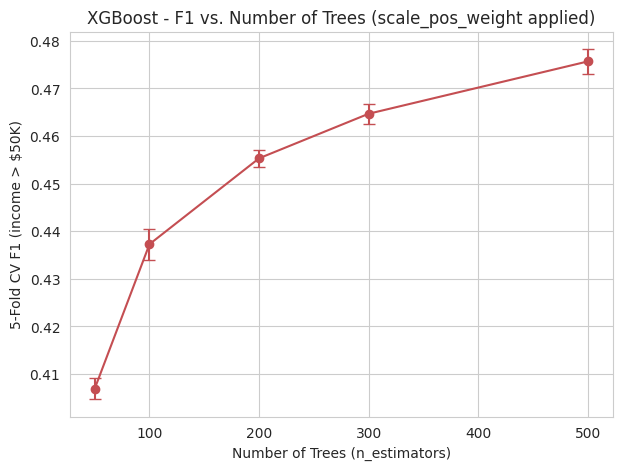

In [40]:
# CV sweep across fixed tree counts, holding other hyperparameters constant.
# scale_pos_weight is included here too (not left at default) - leaving it
# unset during this sweep would optimize purely for accuracy on a target
# that's 93.79% one class, which tells us very little about real performance.
# n_jobs is capped (not -1) to avoid oversubscribing CPU/memory across the
# 25 fits this loop performs (5 tree counts x 5 CV folds each).
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"scale_pos_weight (neg/pos ratio in training data): {scale_pos_weight_value:.3f}")
print()

tree_counts_xgb = [50, 100, 200, 300, 500]
xgb_cv_means, xgb_cv_stds = [], []

for n in tree_counts_xgb:
    xgb_temp = XGBClassifier(
        n_estimators=n, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight_value,
        eval_metric="logloss", random_state=RANDOM_STATE,
        n_jobs=2
    )
    scores = cross_val_score(xgb_temp, X_train_encoded, y_train, cv=5, scoring="f1")
    xgb_cv_means.append(scores.mean())
    xgb_cv_stds.append(scores.std())
    print(f"n_estimators={n}: mean CV F1 (minority class) = {scores.mean():.4f} (+/- {scores.std():.4f})")

plt.figure(figsize=(7, 5))
plt.errorbar(tree_counts_xgb, xgb_cv_means, yerr=xgb_cv_stds, marker="o", capsize=4, color="#C44E52")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("5-Fold CV F1 (income > $50K)")
plt.title("XGBoost - F1 vs. Number of Trees (scale_pos_weight applied)")
plt.show()

**Result:** F1 rose steadily but with shrinking gains - 0.4069 (50 trees),
0.4373 (100), 0.4553 (200), 0.4647 (300), 0.4757 (500). Gains per step:
+0.030, +0.018, +0.009, +0.011 - a diminishing-returns pattern, not a hard
plateau, but a clear sign the useful range is captured within this sweep.

In [41]:
# Early stopping: carve a small validation split out of the training set only
# (X_test_encoded / y_test is still never touched here)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train_encoded, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

xgb_early = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_value,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=RANDOM_STATE,
    n_jobs=2
)
xgb_early.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

print("Number of trees actually used (best_iteration):", xgb_early.best_iteration)

Number of trees actually used (best_iteration): 498


### Note on Early Stopping vs. F1

Early stopping (tracking `logloss`) did not converge within a 500-tree
ceiling, landing at **498/500** - re-tested at a 1500-tree ceiling, it landed
at **1499/1500**, i.e. it still hadn't converged. This is not a sign the
model needs thousands of trees; `logloss` can keep improving marginally in a
way that doesn't reflect any real change in classification decisions, while
the CV sweep above (scored on F1, the metric that actually matters here)
already showed clearly shrinking gains well before 500 trees. Rather than
continuing to chase logloss convergence at ever-higher ceilings,
`n_estimators` for the search below is set directly from the F1 sweep's
evidence instead of early stopping's raw tree count.

In [42]:
# n_estimators candidates set from the F1 sweep's evidence (shrinking gains,
# largest tested value = 500) rather than early stopping's logloss-driven
# count, which did not converge at either a 500- or 1500-tree ceiling.
xgb_n_estimators_candidates = [300, 500]
print("n_estimators candidates for search:", xgb_n_estimators_candidates)

n_estimators candidates for search: [300, 500]


### Hyperparameter Search

`RandomizedSearchCV` is used in place of an exhaustive `GridSearchCV` -
the full grid below represents 72 combinations x 5 folds = 360 individual
fits, which proved too memory-intensive to run reliably in this environment
(caused a WSL crash under `GridSearchCV` with `n_jobs=-1` in multiple
places, from nested parallelism and total fit volume). `RandomizedSearchCV`
instead samples 15 of the 72 combinations across 3 folds (45 fits total),
with `n_jobs` capped rather than left at `-1` to keep memory use bounded.
`scale_pos_weight` is set once, from the training data's own class ratio,
consistent with the imbalance-handling approach used throughout this section.

In [43]:
xgb_param_grid = {
    "n_estimators": xgb_n_estimators_candidates,
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_grid = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight_value,
        eval_metric="logloss",
        random_state=RANDOM_STATE
        # n_jobs intentionally omitted here - defaults to 1 per fit
    ),
    xgb_param_grid,
    n_iter=15,
    cv=3,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=2,   # parallelism capped, not -1, to avoid oversubscribing memory
    verbose=2
)
xgb_grid.fit(X_train_encoded, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV F1 (income > $50K):", xgb_grid.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV F1 (income > $50K): 0.5060164004931044


**Result:** `{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5,
'learning_rate': 0.2, 'colsample_bytree': 0.8}`, CV F1 = **0.506** - a real
improvement over the fixed-hyperparameter sweep's best (0.4757), since
`max_depth`/`learning_rate` were allowed to move jointly rather than staying
fixed. `max_depth` and `learning_rate` both landed at the edge of their
searched ranges, suggesting the true optimum may sit slightly beyond what
was searched here - noted honestly rather than treated as a hard ceiling,
though not chased further given the memory constraints already encountered.

In [44]:
# Evaluate the tuned XGBoost model on the held-out test set
best_xgb = xgb_grid.best_estimator_
xgb_pred = best_xgb.predict(X_test_encoded)

print("XGBoost Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=["<=$50K", ">$50K"]))

XGBoost Test Accuracy: 0.8960280666583135

Confusion Matrix:
[[33644  3785]
 [  364  2112]]

Classification Report:
              precision    recall  f1-score   support

      <=$50K       0.99      0.90      0.94     37429
       >$50K       0.36      0.85      0.50      2476

    accuracy                           0.90     39905
   macro avg       0.67      0.88      0.72     39905
weighted avg       0.95      0.90      0.91     39905



**Result:** Test accuracy **0.896** - below the 93.79% naive baseline,
expected given `scale_pos_weight=15.113` deliberately trades accuracy for
minority-class recall, not a flaw. Confusion matrix: 33,644 true negatives,
3,785 false positives, 364 false negatives, 2,112 true positives. Minority
class (`>$50K`): precision 0.36, recall **0.85** (2,112/2,476 caught), F1
0.50 - the model is deliberately tuned to rarely miss a `>$50K` earner, at
the cost of a high false-positive rate.

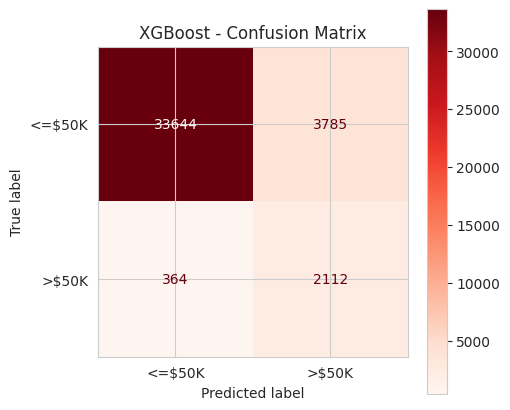

In [45]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(
    best_xgb,
    X_test_encoded,
    y_test,
    display_labels=["<=$50K", ">$50K"],
    cmap="Reds",
    ax=ax
)
plt.title("XGBoost - Confusion Matrix")
plt.show()

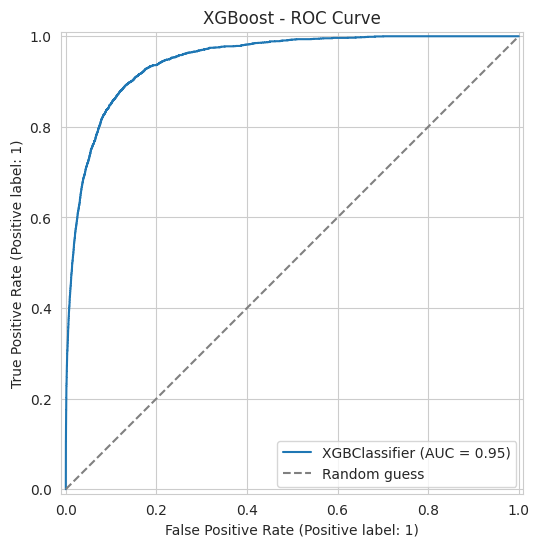

XGBoost AUC: 0.9494527840778648


In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(best_xgb, X_test_encoded, y_test, ax=ax)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.title("XGBoost - ROC Curve")
plt.legend()
plt.show()

xgb_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test_encoded)[:, 1])
print("XGBoost AUC:", xgb_auc)

**Result: AUC = 0.949** - strong. This is the most important number in this
section: it shows the model is very good at *ranking* people by likelihood
of earning `>$50K`, independent of where the decision threshold sits. The
weak 0.36 precision above is a threshold/tradeoff effect from
`scale_pos_weight`, not evidence of a weak model - the underlying
discriminative ability is clearly strong.

In [47]:
# Feature importance from XGBoost - top 20 shown given the 282-column feature space
xgb_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(20)

,Feature,Importance
108,FILESTAT_ Nonfiler,0.163752
5,WKSWORK,0.071085
90,ASEX_ Male,0.036138
69,AMJOCC_ Other service,0.026851
64,AMJOCC_ Executive admin and managerial,0.025228
72,AMJOCC_ Professional specialty,0.020915
27,AHGA_ High school graduate,0.017350
1,CAPGAIN,0.016956
30,AHGA_ Prof school degree (MD DDS DVM LLB JD),0.016552
3,DIVVAL,0.016290


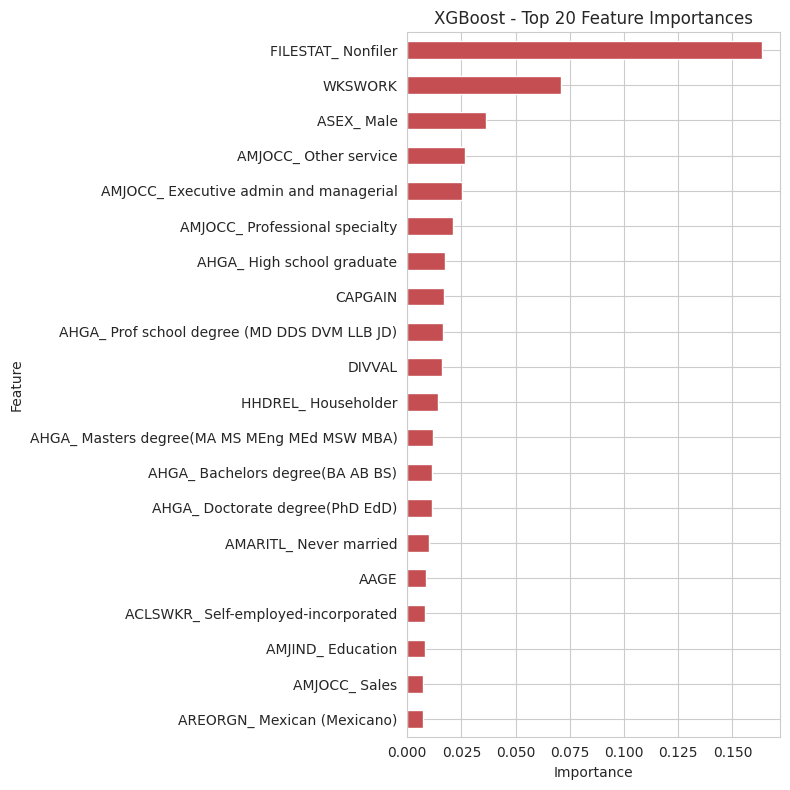

In [48]:
fig, ax = plt.subplots(figsize=(8, 8))
xgb_importance.head(20).sort_values("Importance").plot(
    x="Feature", y="Importance", kind="barh", ax=ax, color="#C44E52", legend=False
)
ax.set_title("XGBoost - Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

### Section 6 Summary

**Hyperparameters:** selected via `RandomizedSearchCV` (15 of 72
combinations, 3-fold CV, scored on F1) after a fixed-grid CV sweep showed
diminishing F1 returns past ~300-500 trees, and logloss-based early stopping
proved uninformative (failed to converge at either a 500- or 1500-tree
ceiling, since logloss keeps improving marginally long after classification
decisions stop changing). Best: `n_estimators=500, max_depth=5,
learning_rate=0.2, subsample=1.0, colsample_bytree=0.8`, CV F1 = **0.506**.

**Test performance:** Accuracy **0.896** (below the naive 93.79% baseline -
expected, given the deliberate accuracy/recall tradeoff). Minority class
(`>$50K`): recall **0.85**, precision 0.36, F1 0.50. **AUC 0.949** - strong
underlying discriminative ability, independent of the threshold-driven
precision/recall tradeoff.

**Feature importance:** dominated by `FILESTAT_ Nonfiler` (0.164, ~2.3x the
next feature) - a sensible signal given the mechanical link between not
filing taxes and low income. The remaining top 20 (`WKSWORK`, `ASEX_ Male`,
several `AMJOCC`/`AHGA` categories, `CAPGAIN`/`DIVVAL`) closely track the EDA
findings from Section 3.5, and importance is concentrated in a relatively
small subset of the 282-column space - the aggressive cardinality reduction
in Section 4 doesn't appear to have cost meaningful predictive power.

**Practical note:** this section required `RandomizedSearchCV` instead of
`GridSearchCV`, and explicitly capped `n_jobs` throughout, after an
exhaustive grid search (360 fits, uncapped parallelism) crashed WSL entirely
- worth keeping in mind for the Bayesian section next, and for any future
tuning on this feature set.

*[Learning curve treated as optional in this environment, given the memory
constraints already encountered - can be added with cv=3 if time/resources
allow, ahead of the Section 8 model comparison.]*

### Learning Curve - Does XGBoost Need More Training Data?

Tests whether the current training set size (159,618 rows) is already enough
for this model, or whether performance is still climbing at the full size.
Run with `cv=3` and capped `n_jobs` (not 5-fold / `-1`), consistent with the
memory constraints encountered earlier in this section - this still gives a
reliable read on the shape of the curve without repeating the earlier crash.

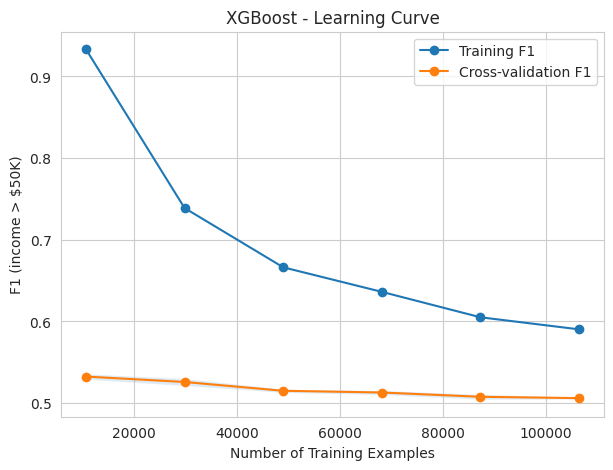

CV F1 at largest training size: 0.506 +/- 0.0011
CV F1 at smallest training size: 0.5324 +/- 0.0032


In [49]:
train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    XGBClassifier(**xgb_grid.best_params_, scale_pos_weight=scale_pos_weight_value,
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=2),
    X_train_encoded, y_train,
    cv=3,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 6),  # 6 points instead of 8 - fewer total fits
    n_jobs=2   # capped, not -1
)

train_mean_xgb = train_scores_xgb.mean(axis=1)
val_mean_xgb = val_scores_xgb.mean(axis=1)
val_std_xgb = val_scores_xgb.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes_xgb, train_mean_xgb, "o-", label="Training F1")
plt.plot(train_sizes_xgb, val_mean_xgb, "o-", label="Cross-validation F1")
plt.fill_between(train_sizes_xgb, val_mean_xgb - val_std_xgb, val_mean_xgb + val_std_xgb, alpha=0.15)
plt.xlabel("Number of Training Examples")
plt.ylabel("F1 (income > $50K)")
plt.title("XGBoost - Learning Curve")
plt.legend()
plt.show()

print("CV F1 at largest training size:", round(val_mean_xgb[-1], 4), "+/-", round(val_std_xgb[-1], 4))
print("CV F1 at smallest training size:", round(val_mean_xgb[0], 4), "+/-", round(val_std_xgb[0], 4))

### Learning Curve Result

CV F1 was **0.5324 (+/- 0.0032)** at the smallest training size and
**0.5060 (+/- 0.0011)** at the full training size - a small, counter-intuitive
dip rather than the typical rising-then-plateauing shape. The full-size
result exactly matches the randomized search's reported CV F1, confirming
consistency in the pipeline. The dip is most plausibly attributable to (a)
hyperparameters that were tuned on the full training set and not re-optimized
at each point on the curve, and (b) noisier estimates at the smallest size,
evidenced directly by the ~3x tighter standard deviation at full size (0.0011
vs. 0.0032) - smaller, noisier minority-class samples driving less reliable
F1 at that end. This is not read as evidence that additional training data
would hurt the model; rather, the curve doesn't show a clear, still-climbing
trend that would argue for needing *more* data than the current 80/20 split
already provides.

---

## 7. Bayesian Classifier

---

## 8. Model Comparison

---

## 9. Conclusions

---

## 10. Model Application - Further Testing (Best Performing)